In [3]:
! nbdime config-git --enable

15:07:37 [INFO] [OK] matplotlib found – plots will be generated.
15:07:37 [INFO] [RUN] ===== STARTING PIPELINE =====
15:07:37 [INFO] [DISCOVER] scanning main folder -> .
15:07:37 [INFO]   [SKIP] '.git' does not start with awake/sleep -> ignored
15:07:37 [INFO]   [SCAN] awake/awake_1
15:07:37 [INFO]     [SESSION] corrected_by_operator: 50 JSON file(s)
15:07:37 [INFO]     [SESSION] raw_inference: 50 JSON file(s)
15:07:37 [INFO]   [SCAN] awake/awake_2
15:07:37 [INFO]     [SESSION] corrected_by_operator: 55 JSON file(s)
15:07:37 [INFO]     [SESSION] raw_inference: 55 JSON file(s)
15:07:37 [INFO]   [SCAN] awake/awake_3
15:07:37 [INFO]     [SESSION] corrected_by_operator: 39 JSON file(s)
15:07:37 [INFO]     [SESSION] raw_inference: 39 JSON file(s)
15:07:37 [INFO]   [SCAN] awake/awake_4
15:07:37 [INFO]     [SESSION] corrected_by_operator: 64 JSON file(s)
15:07:37 [INFO]     [SESSION] raw_inference: 64 JSON file(s)
15:07:37 [INFO]   [SCAN] awake/awake_5
15:07:37 [INFO]     [SESSION] corrected_

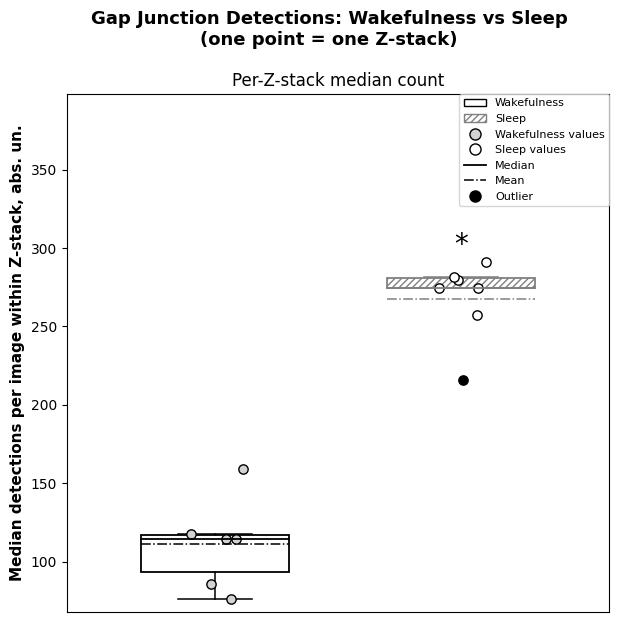

15:07:46 [INFO] [ZSTACK-PLOT] saved -> .\results\zstack_summary\zstack_median_count.png  (n_awake_zstacks=6, n_sleep_zstacks=7)


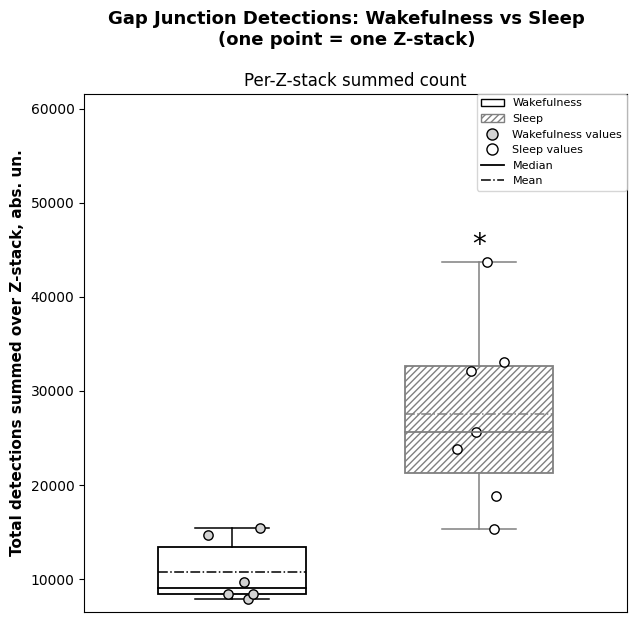

15:07:47 [INFO] [ZSTACK-PLOT] saved -> .\results\zstack_summary\zstack_sum_count.png  (n_awake_zstacks=6, n_sleep_zstacks=7)


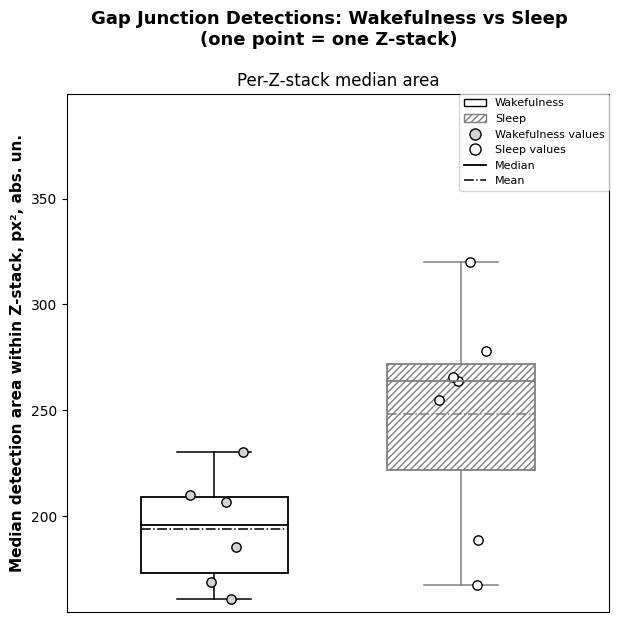

15:07:47 [INFO] [ZSTACK-PLOT] saved -> .\results\zstack_summary\zstack_median_area.png  (n_awake_zstacks=6, n_sleep_zstacks=7)


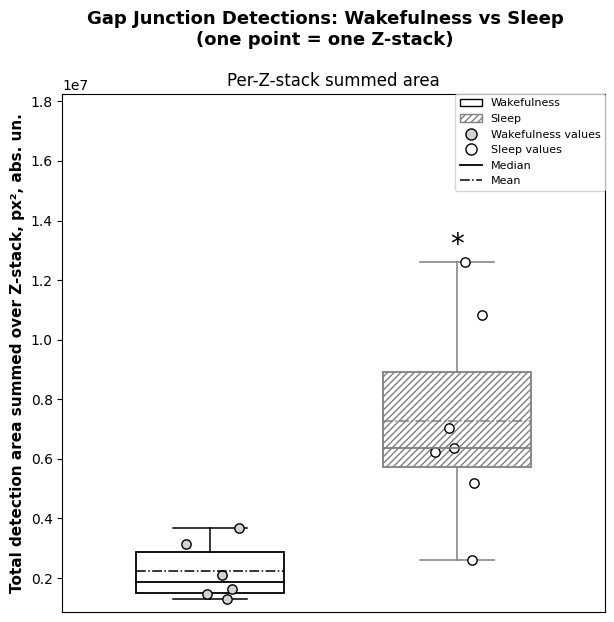

15:07:47 [INFO] [ZSTACK-PLOT] saved -> .\results\zstack_summary\zstack_sum_area.png  (n_awake_zstacks=6, n_sleep_zstacks=7)
15:07:47 [INFO] [RUN] ===== PIPELINE COMPLETE =====
15:07:47 [INFO] [RUN] all outputs saved in: c:\Users\user\Downloads\Yandex_Downloads\631_bat_gj_2024\results


In [ ]:
"""
SINGLE CELL — Gap Junction Detection Pipeline (Filtered, Logged, Plotted)
==========================================================================
Paste this as ONE notebook cell and run it. It will:
  1. Discover awake/sleep folders (with logging)
  2. Apply FILTER 1 (zero-tail exclusion) and FILTER 2 (3-sigma area outlier
     exclusion) per session
  3. Aggregate filtered stats per condition
  4. Draw box-and-whisker plots with jittered points (Sleep on the left,
     Wakefulness on the right; hatched Sleep box, mean/median lines,
     filled outlier markers)

Edit MAIN_FOLDER / OUTPUT_DIR below, then run the cell.
"""

# ═══════════════════════════════════════════════════════════════════
#  CONFIG
# ═══════════════════════════════════════════════════════════════════
REPO_ROOT = Path(".").resolve()
DATA_ROOT = REPO_ROOT / "data"
MAIN_FOLDER      = str(DATA_ROOT if DATA_ROOT.exists() else REPO_ROOT)
OUTPUT_DIR       = str((REPO_ROOT / "results").resolve())
OUTLIER_Z_THRESH = 3.0   # std-deviations from subfolder mean area → flagged as outlier
MAX_DETECTION_AREA = 500  # px² — detections larger than this are dropped at parse time
VERBOSE_FILE_LOGGING = False  # set True for one log line per JSON file loaded
# ═══════════════════════════════════════════════════════════════════

import json, logging, os, csv, statistics
from pathlib import Path
from collections import defaultdict

try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.lines import Line2D
    import numpy as np
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

# ── logging setup ───────────────────────────────────────────────────────
logger = logging.getLogger("gap_junction_pipeline")
logger.setLevel(logging.INFO)
if not logger.handlers:
    _handler = logging.StreamHandler()
    _handler.setFormatter(logging.Formatter("%(asctime)s [%(levelname)s] %(message)s",
                                             datefmt="%H:%M:%S"))
    logger.addHandler(_handler)

if HAS_MPL:
    logger.info("[OK] matplotlib found – plots will be generated.")
else:
    logger.info("[INFO] matplotlib not found – text/CSV report only. "
                 "Install: pip install matplotlib numpy")


# ─────────────────────────────────────────────────────────────────────────────
#  Data loading
# ─────────────────────────────────────────────────────────────────────────────

def load_json_file(filepath):
    if VERBOSE_FILE_LOGGING:
        logger.info(f"  [LOAD] reading JSON -> {filepath}")
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
    except FileNotFoundError:
        logger.error(f"  [LOAD] FILE NOT FOUND -> {filepath}")
        raise
    except json.JSONDecodeError as e:
        logger.error(f"  [LOAD] INVALID JSON in {filepath}: {e}")
        raise
    if VERBOSE_FILE_LOGGING:
        logger.info(f"  [LOAD] ok, {len(data)} image_key(s) in file")
    return data


def bbox_area(det):
    return det["bbox_width"] * det["bbox_height"]


def parse_detections(raw):
    dets = []
    n_dropped_oversize = 0
    for image_key, det_list in raw.items():
        for d in det_list:
            area = bbox_area(d)
            if MAX_DETECTION_AREA is not None and area > MAX_DETECTION_AREA:
                n_dropped_oversize += 1
                continue
            dets.append({
                "image_key":    image_key,
                "label_name":   d.get("label_name", "unknown"),
                "bbox_x":       d["bbox_x"],
                "bbox_y":       d["bbox_y"],
                "bbox_width":   d["bbox_width"],
                "bbox_height":  d["bbox_height"],
                "area":         bbox_area(d),
                "image_width":  d["image_width"],
                "image_height": d["image_height"],
                "score":        d.get("score", float("nan")),
            })
    if VERBOSE_FILE_LOGGING and n_dropped_oversize:
        logger.info(f"  [PARSE] dropped {n_dropped_oversize} oversized detection(s) "
                     f"(> {MAX_DETECTION_AREA}px²)")
    return dets


def discover_structure(main_folder):
    logger.info(f"[DISCOVER] scanning main folder -> {main_folder}")
    main   = Path(main_folder)
    result = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))

    n_subfolders_seen    = 0
    n_subfolders_skipped = 0
    n_sessions_found     = 0
    n_json_files_found   = 0

    for sub in sorted(main.iterdir()):
        if not sub.is_dir():
            continue
        n_subfolders_seen += 1

        name_lower = sub.name.lower()
        if   name_lower.startswith("awake"): condition = "awake"
        elif name_lower.startswith("sleep"): condition = "sleep"
        else:
            logger.info(f"  [SKIP] '{sub.name}' does not start with awake/sleep -> ignored")
            n_subfolders_skipped += 1
            continue

        detection_root = sub / "Detection"
        if not detection_root.exists():
            logger.warning(f"  [SKIP] '{sub.name}' ({condition}) has no Detection/ folder")
            n_subfolders_skipped += 1
            continue

        logger.info(f"  [SCAN] {condition}/{sub.name}")

        sessions_in_subfolder = 0
        for session_dir in sorted(detection_root.iterdir()):
            if not session_dir.is_dir():
                continue
            sessions_in_subfolder += 1
            n_sessions_found += 1

            json_files = sorted(session_dir.glob("*.json"))
            n_json_files_found += len(json_files)

            logger.info(f"    [SESSION] {session_dir.name}: {len(json_files)} JSON file(s)")

            for jf in json_files:
                if VERBOSE_FILE_LOGGING:
                    logger.info(f"      [FOUND] {jf.name}")
                result[condition][sub.name][session_dir.name][jf.stem] = str(jf)

        if sessions_in_subfolder == 0:
            logger.warning(f"  [WARN] {condition}/{sub.name} has a Detection/ folder "
                            f"but no session subdirectories")

    logger.info(f"[DISCOVER] done. subfolders_seen={n_subfolders_seen} "
                f"(skipped={n_subfolders_skipped}), sessions_found={n_sessions_found}, "
                f"json_files_found={n_json_files_found}")

    return result


# ─────────────────────────────────────────────────────────────────────────────
#  FILTER 1 — Zero-tail exclusion
# ─────────────────────────────────────────────────────────────────────────────

def get_valid_stems(sessions):
    logger.info(f"  [FILTER1] checking {len(sessions)} session(s) for zero-tail stems")
    stem_counts = defaultdict(list)
    n_files_loaded = 0
    for session_name, files in sessions.items():
        for stem, fpath in files.items():
            raw  = load_json_file(fpath)
            dets = parse_detections(raw)
            stem_counts[stem].append(len(dets))
            n_files_loaded += 1

    valid = {stem for stem, counts in stem_counts.items() if any(c > 0 for c in counts)}
    excluded = set(stem_counts.keys()) - valid

    logger.info(f"  [FILTER1] loaded {n_files_loaded} file(s) across {len(stem_counts)} "
                f"unique stem(s) -> valid={len(valid)}, zero-tail excluded={len(excluded)}")
    if excluded:
        logger.info(f"  [FILTER1] zero-tail stems: {sorted(excluded)}")

    return valid, excluded


# ─────────────────────────────────────────────────────────────────────────────
#  FILTER 2 — Outlier exclusion (3-sigma on mean area per image)
# ─────────────────────────────────────────────────────────────────────────────

def find_area_outliers(sessions, valid_stems, z_thresh=None):
    if z_thresh is None:
        z_thresh = OUTLIER_Z_THRESH

    logger.info(f"  [FILTER2] scanning {len(sessions)} session(s) for area outliers "
                f"(z_thresh={z_thresh})")

    outliers = {}
    for session_name, files in sessions.items():
        img_mean_areas = {}
        for stem, fpath in files.items():
            if stem not in valid_stems:
                continue
            dets = parse_detections(load_json_file(fpath))
            if not dets:
                continue
            img_mean_areas[stem] = statistics.mean(d["area"] for d in dets)

        if len(img_mean_areas) < 3:
            logger.info(f"    [FILTER2] {session_name}: only {len(img_mean_areas)} "
                        f"valid image(s) -> skipping outlier check (need >= 3)")
            outliers[session_name] = set()
            continue

        vals  = list(img_mean_areas.values())
        mu    = statistics.mean(vals)
        sigma = statistics.pstdev(vals)
        if sigma == 0:
            logger.info(f"    [FILTER2] {session_name}: sigma=0 (no variance) -> "
                        f"skipping outlier check")
            outliers[session_name] = set()
            continue

        bad = {stem for stem, v in img_mean_areas.items()
               if abs(v - mu) > z_thresh * sigma}
        outliers[session_name] = bad

        logger.info(f"    [FILTER2] {session_name}: mean_area={mu:.2f} sigma={sigma:.2f} "
                    f"-> {len(bad)} outlier(s) out of {len(img_mean_areas)} image(s)")
        if bad:
            logger.info(f"      [FILTER2] outlier stems: {sorted(bad)}")

    all_bad = set()
    for bad in outliers.values():
        all_bad |= bad

    logger.info(f"  [FILTER2] done. {len(all_bad)} stem(s) flagged as outlier "
                f"across all sessions (conservative union)")

    return all_bad, outliers


def compute_keep_stems(sessions):
    logger.info(f"[KEEP] computing keep-stems for {len(sessions)} session(s)")
    valid_stems, zero_excluded = get_valid_stems(sessions)
    area_outliers, _per_session = find_area_outliers(sessions, valid_stems)
    keep = valid_stems - area_outliers

    logger.info(f"[KEEP] result: keep={len(keep)}  zero_excluded={len(zero_excluded)}  "
                f"area_outliers={len(area_outliers)}")

    return keep, zero_excluded, area_outliers


# ─────────────────────────────────────────────────────────────────────────────
#  Aggregation (filter-aware)
# ─────────────────────────────────────────────────────────────────────────────

def safe_stats(lst):
    clean = [float(v) for v in lst if v == v]
    if not clean:
        return dict(mean=0, median=0, std=0, minimum=0, maximum=0, total=0, n=0, raw=[])
    return dict(mean=statistics.mean(clean), median=statistics.median(clean),
                std=statistics.pstdev(clean), minimum=min(clean),
                maximum=max(clean), total=sum(clean), n=len(clean), raw=clean)


def aggregate_session(files, keep_stems):
    counts, areas, scores = [], [], []
    for stem, fpath in files.items():
        if stem not in keep_stems:
            continue
        dets = parse_detections(load_json_file(fpath))
        counts.append(len(dets))
        for d in dets:
            areas.append(d["area"])
            scores.append(d["score"])
    return dict(n_images=len(counts),
                total_detections=sum(counts),
                count_stats=safe_stats(counts),
                area_stats=safe_stats(areas),
                score_stats=safe_stats(scores),
                raw_counts=counts, raw_areas=areas)


def aggregate_condition(subfolders):
    logger.info(f"  [AGGREGATE] aggregating {len(subfolders)} subfolder(s)")
    counts, areas = [], []
    total_det = n_images = 0
    for subfolder, sessions in subfolders.items():
        keep, _, _ = compute_keep_stems(sessions)
        for files in sessions.values():
            agg = aggregate_session(files, keep)
            counts.extend(agg["raw_counts"])
            areas.extend(agg["raw_areas"])
            n_images  += agg["n_images"]
            total_det += agg["total_detections"]
    logger.info(f"  [AGGREGATE] done: n_images={n_images}, total_detections={total_det}")
    return dict(n_images=n_images, total_detections=total_det,
                count_stats=safe_stats(counts), area_stats=safe_stats(areas),
                raw_counts=counts, raw_areas=areas)


# ─────────────────────────────────────────────────────────────────────────────
#  Z-STACK level aggregation
#  One Z-stack = one top-level subfolder (e.g. "awake_2024", "sleep_2024").
#  All sessions/images inside that subfolder belong to the same Z-stack.
#  For each Z-stack we compute 4 summary metrics:
#    - median_count : median (over images) of detections-per-image
#    - sum_count    : sum (over images) of detections-per-image
#    - median_area  : median (over ALL detections in the stack) of area
#    - sum_area     : sum (over ALL detections in the stack) of area
# ─────────────────────────────────────────────────────────────────────────────

def aggregate_zstack(subfolder_name, sessions):
    """Pool every image/detection across all sessions in this subfolder
    (= one Z-stack), then compute the 4 per-stack summary metrics."""
    keep, _, _ = compute_keep_stems(sessions)
    counts, areas = [], []
    for files in sessions.values():
        agg = aggregate_session(files, keep)
        counts.extend(agg["raw_counts"])
        areas.extend(agg["raw_areas"])

    return dict(
        subfolder=subfolder_name,
        n_images=len(counts),
        n_detections=len(areas),
        median_count=statistics.median(counts) if counts else float("nan"),
        sum_count=sum(counts) if counts else 0,
        median_area=statistics.median(areas) if areas else float("nan"),
        sum_area=sum(areas) if areas else 0,
    )


def aggregate_zstacks_per_condition(structure):
    """Returns dict[condition] -> list of per-Z-stack metric dicts
    (one entry per subfolder in that condition)."""
    logger.info("[ZSTACK] aggregating per Z-stack (= per subfolder) metrics")
    result = {}
    for cond, subfolders in structure.items():
        stacks = []
        for subfolder, sessions in sorted(subfolders.items()):
            z = aggregate_zstack(subfolder, sessions)
            stacks.append(z)
            logger.info(f"  [ZSTACK] {cond}/{subfolder}: n_images={z['n_images']} "
                        f"n_detections={z['n_detections']} "
                        f"median_count={z['median_count']:.2f} sum_count={z['sum_count']} "
                        f"median_area={z['median_area']:.2f} sum_area={z['sum_area']:.2f}")
        result[cond] = stacks
        logger.info(f"[ZSTACK] {cond}: {len(stacks)} Z-stack(s) total")
    return result


def compare_sessions_per_file(structure):
    logger.info("[COMPARE] building session-vs-session paired rows")
    rows = []
    for condition, subfolders in structure.items():
        for subfolder, sessions in subfolders.items():
            keep, _, _ = compute_keep_stems(sessions)
            names = list(sessions.keys())
            for i in range(len(names)):
                for j in range(i + 1, len(names)):
                    s1, s2 = names[i], names[j]
                    common = (set(sessions[s1]) & set(sessions[s2])) & keep
                    for stem in sorted(common):
                        d1 = parse_detections(load_json_file(sessions[s1][stem]))
                        d2 = parse_detections(load_json_file(sessions[s2][stem]))
                        c1, c2 = len(d1), len(d2)
                        a1 = sum(d["area"] for d in d1) / c1 if c1 else 0
                        a2 = sum(d["area"] for d in d2) / c2 if c2 else 0
                        rows.append(dict(condition=condition, subfolder=subfolder,
                                         session_a=s1, session_b=s2, json_stem=stem,
                                         count_a=c1, count_b=c2, count_diff=c2 - c1,
                                         mean_area_a=a1, mean_area_b=a2, area_diff=a2 - a1))
    logger.info(f"[COMPARE] done: {len(rows)} paired row(s) built")
    return rows


# ─────────────────────────────────────────────────────────────────────────────
#  Text report
# ─────────────────────────────────────────────────────────────────────────────

def fmt(v, d=2): return f"{v:.{d}f}"

def write_text_report(structure, cond_aggs, output_path):
    lines = []
    sep   = "=" * 72
    lines += [sep, "  GAP JUNCTION DETECTION – AWAKE vs SLEEP COMPARISON REPORT", sep,
              f"\n  (filters applied: zero-tail exclusion, "
              f"{OUTLIER_Z_THRESH}-sigma area outlier exclusion, "
              f"max detection area {MAX_DETECTION_AREA}px²)"]

    lines.append("\n── CONDITION-LEVEL SUMMARY ──────────────────────────────────────────")
    for cond in ("awake", "sleep"):
        if cond not in cond_aggs:
            lines.append(f"\n  [{cond.upper()}]  No data found."); continue
        agg = cond_aggs[cond]
        lines += [
            f"\n  [{cond.upper()}]",
            f"    images           : {agg['n_images']}",
            f"    total detections : {agg['total_detections']}",
            f"    mean count/image : {fmt(agg['count_stats']['mean'])}  ± {fmt(agg['count_stats']['std'])}",
            f"    mean area/det    : {fmt(agg['area_stats']['mean'])}  ± {fmt(agg['area_stats']['std'])}",
            f"    median area/det  : {fmt(agg['area_stats']['median'])}",
        ]

    if "awake" in cond_aggs and "sleep" in cond_aggs:
        d_cnt  = cond_aggs["sleep"]["count_stats"]["mean"] - cond_aggs["awake"]["count_stats"]["mean"]
        d_area = cond_aggs["sleep"]["area_stats"]["mean"]  - cond_aggs["awake"]["area_stats"]["mean"]
        lines += ["\n  SLEEP – AWAKE  (positive = higher in sleep)",
                  f"    Δ mean count/image : {d_cnt:>+10.2f}",
                  f"    Δ mean area/det    : {d_area:>+10.2f}"]

    lines.append("\n── SUBFOLDER BREAKDOWN ──────────────────────────────────────────────")
    for cond in ("awake", "sleep"):
        if cond not in structure: continue
        lines.append(f"\n  Condition: {cond.upper()}")
        for subfolder, sessions in sorted(structure[cond].items()):
            keep, zero_excluded, area_outliers = compute_keep_stems(sessions)
            lines.append(f"\n    Subfolder: {subfolder}  "
                         f"(kept={len(keep)}, zero_excluded={len(zero_excluded)}, "
                         f"area_outliers={len(area_outliers)})")
            for session_name, files in sorted(sessions.items()):
                agg = aggregate_session(files, keep)
                lines += [
                    f"\n      Session: {session_name}",
                    f"        images           : {agg['n_images']}",
                    f"        total detections : {agg['total_detections']}",
                    f"        mean count/image : {fmt(agg['count_stats']['mean'])}  ± {fmt(agg['count_stats']['std'])}",
                    f"        mean area/det    : {fmt(agg['area_stats']['mean'])}  ± {fmt(agg['area_stats']['std'])}",
                ]

    srows = compare_sessions_per_file(structure)
    if srows:
        lines.append("\n── SESSION-vs-SESSION  (same JSON file, filtered) ───────────────────")
        cur = None
        for r in srows:
            key = (r["condition"], r["subfolder"], r["session_a"], r["session_b"])
            if key != cur:
                cur = key
                lines += [
                    f"\n  [{r['condition'].upper()}] {r['subfolder']} | {r['session_a']}  vs  {r['session_b']}",
                    f"  {'JSON stem':<40} {'cnt_a':>6} {'cnt_b':>6} {'Δcnt':>7} {'area_a':>9} {'area_b':>9} {'Δarea':>9}",
                    "  " + "-" * 68,
                ]
            lines.append(f"  {r['json_stem']:<40} {r['count_a']:>6} {r['count_b']:>6} "
                         f"{r['count_diff']:>+7} {r['mean_area_a']:>9.2f} "
                         f"{r['mean_area_b']:>9.2f} {r['area_diff']:>+9.2f}")

    lines.append(f"\n{sep}\n")
    report_text = "\n".join(lines)
    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(report_text)
    logger.info(f"[REPORT] saved -> {output_path}")
    return report_text


# ─────────────────────────────────────────────────────────────────────────────
#  CSV export (filter-aware)
# ─────────────────────────────────────────────────────────────────────────────

def write_csv(structure, out_path):
    rows = []
    for cond, subfolders in structure.items():
        for subfolder, sessions in subfolders.items():
            keep, _, _ = compute_keep_stems(sessions)
            for session_name, files in sessions.items():
                for stem, fpath in files.items():
                    if stem not in keep:
                        continue
                    dets   = parse_detections(load_json_file(fpath))
                    cnt    = len(dets)
                    areas  = [d["area"]  for d in dets]
                    scores = [d["score"] for d in dets]
                    rows.append({
                        "condition":    cond,
                        "subfolder":    subfolder,
                        "session":      session_name,
                        "json_stem":    stem,
                        "n_detections": cnt,
                        "mean_area":    statistics.mean(areas)   if areas  else 0,
                        "median_area":  statistics.median(areas) if areas  else 0,
                        "std_area":     statistics.pstdev(areas) if areas  else 0,
                        "mean_score":   statistics.mean(scores)  if scores else 0,
                        "total_area":   sum(areas),
                    })
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    with open(out_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()) if rows else [])
        writer.writeheader(); writer.writerows(rows)
    logger.info(f"[CSV] saved -> {out_path}")


# ─────────────────────────────────────────────────────────────────────────────
#  Outlier helper for plotting (IQR rule — purely visual, separate from the
#  3-sigma FILTER 2 used to exclude data upstream)
# ─────────────────────────────────────────────────────────────────────────────

def iqr_outliers(values):
    vals = sorted(float(v) for v in values if v == v)
    if len(vals) < 4:
        return vals, []
    q1 = statistics.median(vals[: len(vals)//2])
    q3 = statistics.median(vals[(len(vals)+1)//2:])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    inliers  = [v for v in vals if lo <= v <= hi]
    outliers = [v for v in vals if v < lo or v > hi]
    return inliers, outliers


# ─────────────────────────────────────────────────────────────────────────────
#  Plot — box-and-whisker with jittered points (Wakefulness vs Sleep style)
# ─────────────────────────────────────────────────────────────────────────────

def _box_with_points(ax, awake_vals, sleep_vals, ylabel, title, rng):
    awake_in, awake_out = iqr_outliers(awake_vals)
    sleep_in, sleep_out = iqr_outliers(sleep_vals)

    positions = [1, 2]
    # Wakefulness is drawn at position 1 (left), Sleep at position 2 (right).
    # NOTE: box body / whiskers are drawn from inlier-only data (so a single
    # extreme outlier doesn't blow out the visual scale of the box itself).
    # But the mean/median LINES below are computed from the FULL dataset
    # (including outliers) and drawn manually — see the fix below — so the
    # mean line on the plot reflects the true mean of all data, not just
    # the inliers. Without this, removing outliers before boxplot() silently
    # made the mean line collapse toward the median, which is misleading.
    box = ax.boxplot(
        [awake_in if awake_in else awake_vals,
         sleep_in if sleep_in else sleep_vals],
        positions=positions, widths=0.6, showmeans=False, meanline=False,
        showfliers=False, patch_artist=True,
        medianprops=dict(linewidth=0),       # hide matplotlib's own median;
                                              # we draw the TRUE median below
        whiskerprops=dict(color="black", linewidth=1.1),
        capprops=dict(color="black", linewidth=1.1),
        boxprops=dict(color="black", linewidth=1.3),
    )

    # box["boxes"][0] = Wakefulness (left), box["boxes"][1] = Sleep (right)
    box["boxes"][0].set_facecolor("white")
    box["boxes"][0].set_edgecolor("black")
    box["boxes"][1].set_facecolor("white")
    box["boxes"][1].set_edgecolor("gray")
    box["boxes"][1].set_hatch("/////")
    for part in ["whiskers", "caps"]:
        for i, line in enumerate(box[part]):
            if i >= len(box[part]) / 2:
                line.set_color("gray")

    # ── Draw TRUE mean (dash-dot) and TRUE median (solid) computed from the
    # FULL dataset (awake_vals / sleep_vals), not the outlier-trimmed subset
    # used for the box body. This is what makes the mean line accurate when
    # outliers are present. ─────────────────────────────────────────────
    box_half_width = 0.6 / 2
    for pos, vals, line_color in [(positions[0], awake_vals, "black"),
                                   (positions[1], sleep_vals, "gray")]:
        if not vals:
            continue
        true_median = statistics.median(vals)
        true_mean   = statistics.mean(vals)
        x0, x1 = pos - box_half_width, pos + box_half_width
        ax.plot([x0, x1], [true_median, true_median],
                color=line_color, linewidth=1.3, linestyle="-", zorder=5)
        ax.plot([x0, x1], [true_mean, true_mean],
                color=line_color, linewidth=1.1, linestyle="-.", zorder=5)

    def jitter(values, center, width=0.12):
        values = np.asarray(values, dtype=float)
        return center + rng.uniform(-width, width, size=len(values))

    if awake_in:
        ax.scatter(jitter(awake_in, positions[0]), awake_in,
                   facecolor="lightgray", edgecolor="black", s=45, zorder=3,
                   label="Wakefulness values")
    if sleep_in:
        ax.scatter(jitter(sleep_in, positions[1]), sleep_in,
                   facecolor="white", edgecolor="black", s=45, zorder=3,
                   label="Sleep values")

    have_outliers = bool(awake_out) or bool(sleep_out)
    if awake_out:
        ax.scatter(jitter(awake_out, positions[0], width=0.03), awake_out,
                   facecolor="black", edgecolor="black", s=45, zorder=4,
                   label="Outlier")
    if sleep_out:
        ax.scatter(jitter(sleep_out, positions[1], width=0.03), sleep_out,
                   facecolor="black", edgecolor="black", s=45, zorder=4,
                   label="Outlier" if not awake_out else None)

    try:
        a_q1 = statistics.median(sorted(awake_vals)[:len(awake_vals)//2] or awake_vals)
        a_q3 = statistics.median(sorted(awake_vals)[(len(awake_vals)+1)//2:] or awake_vals)
        s_q1 = statistics.median(sorted(sleep_vals)[:len(sleep_vals)//2] or sleep_vals)
        s_q3 = statistics.median(sorted(sleep_vals)[(len(sleep_vals)+1)//2:] or sleep_vals)
        boxes_dont_overlap = (a_q1 > s_q3) or (s_q1 > a_q3)
    except (statistics.StatisticsError, IndexError):
        boxes_dont_overlap = False

    all_vals = list(awake_vals) + list(sleep_vals)
    data_min, data_max = min(all_vals), max(all_vals)
    data_range = data_max - data_min if data_max > data_min else 1
    ax.set_ylim(data_min - 0.04 * data_range, data_max + 0.5 * data_range)

    if boxes_dont_overlap and awake_vals and sleep_vals:
        top_group = 1 if statistics.median(awake_vals) > statistics.median(sleep_vals) else 2
        star_y = data_max + 0.01 * data_range
        ax.text(top_group, star_y, "*", fontsize=20, ha="center", va="bottom", zorder=10)

    

    ax.set_xlim(0.4, 2.6)
    ax.set_xticks([])
    ax.set_ylabel(ylabel, fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=12)

    legend_elements = [
        mpatches.Patch(facecolor="white", edgecolor="black", label="Wakefulness"),
        mpatches.Patch(facecolor="white", edgecolor="gray", hatch="/////", label="Sleep"),
        Line2D([0], [0], marker="o", color="w", label="Wakefulness values",
               markerfacecolor="lightgray", markeredgecolor="black", markersize=8),
        Line2D([0], [0], marker="o", color="w", label="Sleep values",
               markerfacecolor="white", markeredgecolor="black", markersize=8),
        Line2D([0], [0], color="black", linewidth=1.3, linestyle="-",
               label="Median"),
        Line2D([0], [0], color="black", linewidth=1.1, linestyle="-.",
               label="Mean"),
    ]
    if have_outliers:
        legend_elements.append(
            Line2D([0], [0], marker="o", color="w", label="Outlier",
                   markerfacecolor="black", markeredgecolor="black", markersize=8))
    ax.legend(handles=legend_elements, loc="upper right",
              frameon=True, fontsize=8, borderaxespad=0)


def make_plots(cond_aggs, out_dir):
    if not HAS_MPL:
        logger.info("[SKIP] Plots require matplotlib.")
        return
    os.makedirs(out_dir, exist_ok=True)
    rng = np.random.default_rng(seed=42)

    awake_counts = cond_aggs.get("awake", {}).get("raw_counts", [])
    sleep_counts = cond_aggs.get("sleep", {}).get("raw_counts", [])
    awake_areas  = cond_aggs.get("awake", {}).get("raw_areas", [])
    sleep_areas  = cond_aggs.get("sleep", {}).get("raw_areas", [])

    fig, axes = plt.subplots(1, 2, figsize=(13, 7))
    fig.suptitle("Gap Junction Detections: Wakefulness vs Sleep (filtered)",
                fontsize=14, fontweight="bold")

    _box_with_points(axes[0], awake_counts, sleep_counts,
                      ylabel="Number of detections per image, abs. un.",
                      title="Detections per image", rng=rng)
    _box_with_points(axes[1], awake_areas, sleep_areas,
                      ylabel="Detection area, px², abs. un.",
                      title="Area per detection", rng=rng)

    plt.tight_layout(rect=[0, 0, 0.88, 1])
    p1 = os.path.join(out_dir, "boxplot_with_points_awake_vs_sleep.png")
    fig.savefig(p1, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    logger.info(f"[PLOT] saved -> {p1}")


# ─────────────────────────────────────────────────────────────────────────────
#  Z-STACK level plots — 4 variations, one point per Z-stack (= per subfolder)
#  instead of one point per image / one point per detection.
#    1. median_count : median detections-per-image, computed within each stack
#    2. sum_count    : total detections summed over the whole stack
#    3. median_area  : median detection area, computed within each stack
#    4. sum_area     : total detection area summed over the whole stack
# ─────────────────────────────────────────────────────────────────────────────

def make_zstack_plots(structure, out_dir):
    """Draw 4 separate box-plots-with-points, each using one Z-stack
    (= one subfolder) as the unit of observation, instead of one image
    or one detection. Each figure is saved on its own."""
    if not HAS_MPL:
        logger.info("[SKIP] Z-stack plots require matplotlib.")
        return

    os.makedirs(out_dir, exist_ok=True)
    zstacks = aggregate_zstacks_per_condition(structure)

    awake_stacks = zstacks.get("awake", [])
    sleep_stacks = zstacks.get("sleep", [])

    n_awake_zstacks = len(awake_stacks)
    n_sleep_zstacks = len(sleep_stacks)
    logger.info(f"[ZSTACK-PLOT] {n_awake_zstacks} awake Z-stack(s), "
                f"{n_sleep_zstacks} sleep Z-stack(s) available for plotting")

    variations = [
        ("median_count", "Median detections per image within Z-stack, abs. un.",
         "Per-Z-stack median count", "zstack_median_count.png"),
        ("sum_count", "Total detections summed over Z-stack, abs. un.",
         "Per-Z-stack summed count", "zstack_sum_count.png"),
        ("median_area", "Median detection area within Z-stack, px², abs. un.",
         "Per-Z-stack median area", "zstack_median_area.png"),
        ("sum_area", "Total detection area summed over Z-stack, px², abs. un.",
         "Per-Z-stack summed area", "zstack_sum_area.png"),
    ]

    saved_paths = []
    for metric_key, ylabel, title, filename in variations:
        awake_vals = [z[metric_key] for z in awake_stacks if z[metric_key] == z[metric_key]]
        sleep_vals = [z[metric_key] for z in sleep_stacks if z[metric_key] == z[metric_key]]

        if not awake_vals and not sleep_vals:
            logger.warning(f"[ZSTACK-PLOT] no data for metric '{metric_key}' -> skipping")
            continue

        rng = np.random.default_rng(seed=42)
        fig, ax = plt.subplots(figsize=(7, 7))
        fig.suptitle(f"Gap Junction Detections: Wakefulness vs Sleep\n"
                     f"(one point = one Z-stack)", fontsize=13, fontweight="bold",
                     y=0.97)

        _box_with_points(ax, awake_vals, sleep_vals, ylabel=ylabel, title=title, rng=rng)

        fig.subplots_adjust(top=0.85)
        p = os.path.join(out_dir, filename)
        fig.savefig(p, dpi=300)
        plt.show()
        plt.close(fig)
        saved_paths.append(p)
        logger.info(f"[ZSTACK-PLOT] saved -> {p}  "
                    f"(n_awake_zstacks={len(awake_vals)}, n_sleep_zstacks={len(sleep_vals)})")

    return saved_paths

# ─────────────────────────────────────────────────────────────────────────────
#  ENTRY POINT — discover, filter, aggregate, report, export, plot
# ─────────────────────────────────────────────────────────────────────────────

def run(main_folder=MAIN_FOLDER, output_dir=OUTPUT_DIR):
    if not os.path.isdir(main_folder):
        logger.error(f"[RUN] folder not found: {main_folder}")
        logger.error("[RUN] edit MAIN_FOLDER at the top of this cell and re-run")
        return None, None

    os.makedirs(output_dir, exist_ok=True)
    logger.info("[RUN] ===== STARTING PIPELINE =====")
    structure = discover_structure(main_folder)

    if not structure:
        logger.error("[RUN] no awake/sleep subfolders with Detection/session_*/*.json found")
        return None, None

    total_raw = sum(len(f) for sf in structure.values()
                           for sess in sf.values() for f in sess.values())
    logger.info(f"[RUN] found {total_raw} JSON file(s) across {len(structure)} condition(s)")

    cond_aggs = {}
    for cond in ("awake", "sleep"):
        if cond not in structure:
            logger.warning(f"[RUN] no '{cond}' condition found in structure")
            continue
        logger.info(f"[RUN] aggregating condition '{cond}'")
        cond_aggs[cond] = aggregate_condition(structure[cond])

    # make_plots(cond_aggs, os.path.join(output_dir, "detections_summary"))
    make_zstack_plots(structure, os.path.join(output_dir, "zstack_summary"))

    logger.info("[RUN] ===== PIPELINE COMPLETE =====")
    logger.info(f"[RUN] all outputs saved in: {os.path.abspath(output_dir)}")

    return structure, cond_aggs


# Actually run it now, so this cell produces visible log output, report, CSV,
# and the plot immediately.
structure, cond_aggs = run(MAIN_FOLDER, OUTPUT_DIR)